## **1. Pandas**

* reference: https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html

### **1-1. 필요 패키지 설치**

* `pandas` 라이브러리를 설치
* 이미 설치되어 있다면 'Requirement already satisfied' 메시지가 나타납니다.

In [ ]:
!pip install pandas

### **1-2. Data 다운로드**

> **1. 링크를 통해 데이터셋을 다운로드 하는 경우**

In [ ]:
!curl -o iris.data https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data

In [ ]:
# 데이터가 저장된 위치 확인
!pwd

In [ ]:
# 현재 위치의 파일 확인
!ls

In [ ]:
import pandas as pd

df_link = pd.read_csv('iris.data', header=None)
df_link
# df_link.head()

> **2. 기확보한 데이터셋을 불러와 사용하는 경우**

In [ ]:
from google.colab import drive

drive.mount('./MyDrive')

In [ ]:
df_local = pd.read_csv('/content/MyDrive/MyDrive/Colab Notebooks/머신러닝실습/iris.data', header=None)
df_local

### **1-3. Exploratory Data Analysis (EDA)**

: 데이터를 이해하고 숨겨진 패턴이나 이상치를 발견하기 위한 단계

> **columns**

In [ ]:
# sepal: 꽃받침 / petal: 꽃잎
df_link.columns = [
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width',
    'species',
]

df_link

In [ ]:
df_link.columns

> **head(), tail()**

In [ ]:
# head(n): 상위 n개 행 출력
df_link.head(5)

In [ ]:
# tail(n): 하위 n개 행 출력
df_link.tail(15)

> **unique(), describe(), sort_values()**

In [ ]:
# species 컬럼에 있는 고유한 값 확인
df_link.species.unique()

In [ ]:
# describe(): 숫자형 컬럼에 대한 기술 통계량 요약
df_link.describe()

In [ ]:
# sepal_length 컬럼을 기준으로 데이터 프레임 정렬 (기본: 오름차순)
df_link.sort_values(by='sepal_length')

> **loc, iloc**

| **구분** | **loc** | **iloc** |
| --- | --- | --- |
| **탐색 대상** | 인덱스 이름(index label) | 정수형 위치 인덱스(integer position) |
| **범위 지정** | 범위의 끝 포함 | 범위의 끝 제외 |

In [ ]:
# loc[row, column]: 특정 행과 컬럼의 값을 가져옴
df_link.loc[3, 'sepal_length']

In [ ]:
# loc[:n]:0부터 n까지모든 행을 가져옴
df_link.loc[:3]

In [ ]:
# 모든 행과 처음 3개 컬럼 선택
df_link.loc[:, list(df_link.columns)[:3]]

In [ ]:
# pandas 데이터프레임을 numpy 배열로 변환
df_link.to_numpy()[:5]

In [ ]:
# 2-9번째 행, 1-3번째 열
df_link.iloc[2:10, 1:4]

### **1-4. DataFrame 생성**

* key: column 이름
* value: column의 데이터

In [ ]:
df_custom = pd.DataFrame({
    'Name': [
        'Kyutae',
        'Yerim',
        'Yoonseok',
    ],
    'Age': [21, 19, 25],
    'Sex': ['male', 'female', 'male'],
})

df_custom

In [ ]:
df_custom.Name

In [ ]:
df_custom['Name']

### **1-5. Boolean Indexing**

* 특정 조건을 만족하는 행을 선택
* 조건을 만족하는 행만 True, 만족하지 않으면 False로 평가하여 필터링

In [ ]:
# Age가 20 이상인 행
df_custom[df_custom['Age'] >= 20]

In [ ]:
# Sex 컬럼의 값이 female인 모든 행

df_custom[df_custom['Sex'] == 'female']
# df_custom[df_custom['Sex'].isin(['female'])]

### **1-6. Missing Values**

In [ ]:
df_custom['height'] = [164, None, None]

In [ ]:
df_custom

In [ ]:
# isna(): 각 요소가 누락된 값(NaN)인지 여부를 나타냄
df_custom.isna()

In [ ]:
# value_counts(): True와 False 개수를 세어 출력
df_custom['height'].isna().value_counts()

In [ ]:
# isnull(): null인지 판단(True/False), sum(): True의 개수
df_custom.height.isnull().sum()

In [ ]:
# dropna(): 누락된 값이 있는 모든 행 제거
df_custom.dropna()

In [ ]:
# fillna(): 누락된 값을 특정 값으로 채움
df_custom.fillna(180)

# **2. Numpy**

In [ ]:
import numpy as np

### **2-1. 배열 만들기**

In [ ]:
a = np.array([1, 2, 3]) # rank 1
b = np.array([[1, 2, 3], [4, 5, 6]]) # rank 2

In [ ]:
a, a.shape

In [ ]:
b, b.shape

In [ ]:
bool_idx = [b > 2]
bool_idx

In [ ]:
b[tuple(bool_idx)]

### **2-2. Dtype 확인**

In [ ]:
a = np.array([1, 2])
a.dtype

In [ ]:
b = np.array([1.0, 2.0])
b.dtype

In [ ]:
b = np.array([1.0, 2.0], dtype=np.int64)
b, b.dtype

### **2-3. 숫자 배열 생성**

In [ ]:
# 0으로 채워진 배열 생성
a = np.zeros((3, 4))
a

In [ ]:
# 1로 채워진 배열 생성
b = np.ones((2, 2))
b

In [ ]:
# 특정 값으로 채운 배열 생성
c = np.full((2, 3), 5)
c

In [ ]:
# identity matrix
d = np.eye(5)
d

In [ ]:
# random한 값으로 채운 배열 생성
e = np.random.random((3, 2))
e

### **2-4. 배열 간 연산**

In [ ]:
x = np.array([[1, 2], [3, 4]], dtype=np.float64)
y = np.array([[5, 6], [7, 8]], dtype=np.float64)

In [ ]:
x

In [ ]:
y

In [ ]:
np.add(x, y)

In [ ]:
np.subtract(x, y)

In [ ]:
np.divide(x, y)

In [ ]:
# 제곱근
np.sqrt(x)

In [ ]:
x = np.array([[1, 2], [3, 4]])
y = np.array([[5, 6], [7, 8]])

v = np.array([9, 10])
w = np.array([11, 12])

In [ ]:
v.dot(w)

In [ ]:
np.dot(v, w)

In [ ]:
x.dot(v), np.dot(x, v)

In [ ]:
x.dot(y)

In [ ]:
x

In [ ]:
print(np.sum(x))
print(np.sum(x, axis=0)) # column
print(np.sum(x, axis=1)) # row

### **2-5. Broadcasting**

: 서로 다른 형상(shape)을 가진 배열에 대해 산술 연산을 수행할 수 있도록 하는 메커니즘

In [ ]:
a = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])
b = np.array([1, 0, 1])

In [ ]:
a

In [ ]:
b

In [ ]:
a + b

# **3. 실습과제**

### **과제 1**
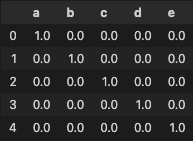
* 위와 같은 구성의 dataframe을 생성하세요. (단, numpy를 사용할 것)
* column 명도 바꿔주세요.

In [ ]:
import pandas as pd
import numpy as np

# Your code here


### **과제 2**

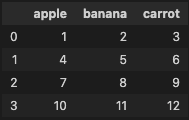
* 위와 같은 데이터프레임을 생성하세요.
* 사과는 4개 이상, 당근은 12개 미만인 행(row)를 추출하세요. (결과는 아래와 같아야 함)

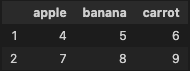

In [ ]:
# 데이터 프레임을 생성
# Your code here


In [ ]:
# 사과는 4개 이상, 당근은 12개 미만인 행 추출
# Your code here
